In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("../data/exercise_dataset.csv")
df.head()

,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4
3,4,Exercise 5,127.183858,79.477008,82.984456,33,Male,39,170,33.729552,Sunny,10
4,5,Exercise 10,416.318374,89.960226,85.643174,29,Female,34,118,23.286113,Cloudy,3


In [4]:
fitness_df = df[["Duration", "Heart Rate", "Calories Burn"]]
fitness_df.head()

,Duration,Heart Rate,Calories Burn
0,37,170,286.959851
1,43,142,343.453036
2,20,148,261.223465
3,39,170,127.183858
4,34,118,416.318374


In [5]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(fitness_df)

In [6]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

In [7]:
pca_data.shape

(3864, 2)

In [8]:
pca.explained_variance_ratio_

array([0.34558125, 0.33761013])

In [9]:
pca.explained_variance_ratio_.sum()

np.float64(0.6831913781237202)

In [10]:
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,-0.981499,0.327006
1,0.245048,0.321554
2,-0.785335,-1.398701
3,-1.971350,0.201106
4,1.243779,-0.684332


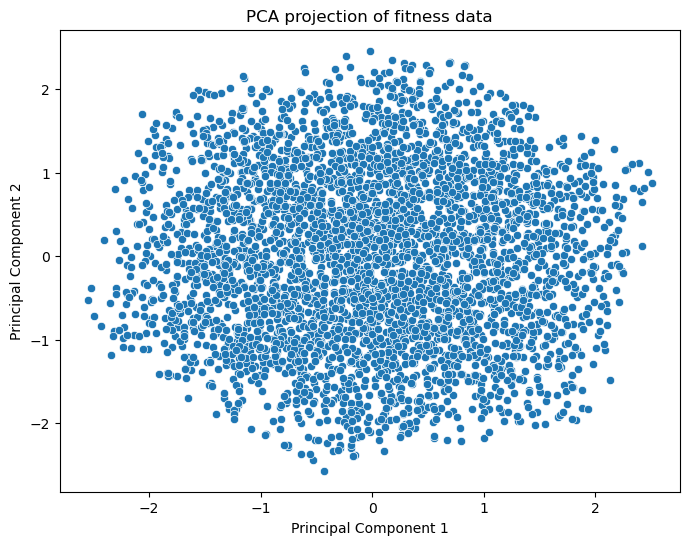

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2")
plt.title("PCA projection of fitness data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [12]:
pca_df["Duration"] = fitness_df["Duration"].values
pca_df["Heart Rate"] = fitness_df["Heart Rate"].values
pca_df["Calories Burn"] = fitness_df["Calories Burn"].values
pca_df.head()

,PC1,PC2,Duration,Heart Rate,Calories Burn
0,-0.981499,0.327006,37,170,286.959851
1,0.245048,0.321554,43,142,343.453036
2,-0.785335,-1.398701,20,148,261.223465
3,-1.971350,0.201106,39,170,127.183858
4,1.243779,-0.684332,34,118,416.318374


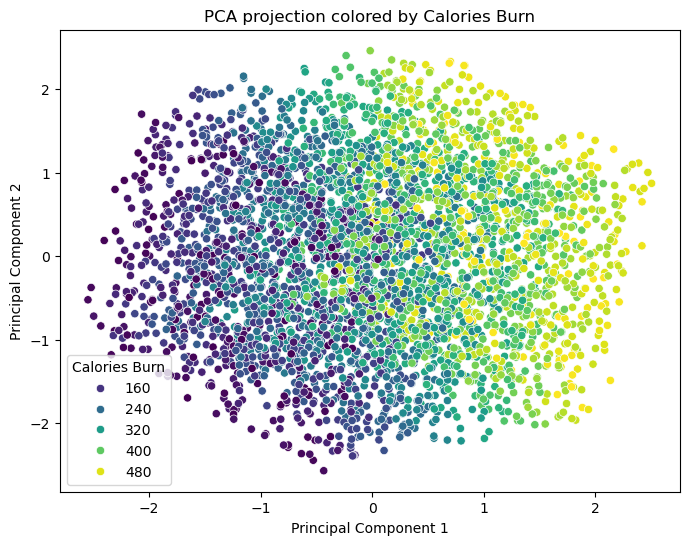

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Calories Burn", palette="viridis")
plt.title("PCA projection colored by Calories Burn")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## PCA analysis

In this section, PCA is used to reduce the three selected variables (Duration, Heart Rate, and Calories Burn) into two principal components.

This makes the data easier to visualize while preserving as much variation as possible. The goal is to explore whether the reduced representation reveals any structure, spread, or possible outliers in the fitness data.

## PCA Conclusion

The dataset was reduced from three variables to two principal components.

The first two components explain about 68% of the total variance, which means most of the information is preserved.

The visualization shows a continuous spread of data rather than clear clusters, suggesting that the dataset does not have strong group structures.

However, a gradient in calories burned can be observed, indicating that this variable still influences the overall structure of the data.

## Interpretation of PCA

The dataset was reduced from three variables (Duration, Heart Rate, Calories Burn) to two principal components.

The first two components explain approximately 68% of the total variance, which means that most of the information is preserved in the reduced dataset.

The visualization shows a continuous spread rather than clear clusters, suggesting that the data does not form distinct groups.

However, a gradient in calories burned can be observed, indicating that this variable still influences the structure of the data.

## Connection to Data Reduction

PCA is a data reduction technique that transforms the original variables into a smaller number of components while preserving as much information as possible.

In this case, three variables were reduced to two components, making the data easier to visualize and interpret.

This follows the concept of data reduction presented in the lecture.

## PCA Step 1: Standardization and Covariance Matrix

Before PCA, the numerical variables must be standardized so they are on the same scale.

In this project, I use the variables:
- Duration
- Heart Rate
- Calories Burn

Standardization is important because PCA is sensitive to scale. Variables with larger values could otherwise dominate the result.

After scaling, I calculate the covariance matrix to understand how the variables move together.
This is an important step in PCA because the principal components are derived from the covariance structure of the data.

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Select numerical variables for PCA
pca_features = ["Duration", "Heart Rate", "Calories Burn"]

X = df[pca_features].copy()

# Drop missing values in selected columns
X = X.dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier reading
X_scaled_df = pd.DataFrame(X_scaled, columns=pca_features)

print("Standardized data (first 5 rows):")
display(X_scaled_df.head())

# Covariance matrix
cov_matrix = np.cov(X_scaled_df, rowvar=False)

cov_df = pd.DataFrame(cov_matrix, index=pca_features, columns=pca_features)

print("Covariance matrix:")
display(cov_df)

Standardized data (first 5 rows):


,Duration,Heart Rate,Calories Burn
0,-0.271241,1.289089,-0.128672
1,0.238771,0.094779,0.359122
2,-1.716274,0.350703,-0.350894
3,-0.101237,1.289089,-1.508268
4,-0.526247,-0.928915,0.988282


Covariance matrix:


,Duration,Heart Rate,Calories Burn
Duration,1.000259,0.014945,0.021799
Heart Rate,0.014945,1.000259,-0.035898
Calories Burn,0.021799,-0.035898,1.000259


## PCA Step 2: Eigenvalues and Eigenvectors

Eigenvectors represent the directions of maximum variance in the data.

Eigenvalues represent how much variance is explained by each direction.

The first principal component (PC1) corresponds to the eigenvector with the highest eigenvalue.

In [15]:
# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[0.9506719  1.01309257 1.03701213]

Eigenvectors:
[[-0.46597289  0.8676285   0.17346485]
 [ 0.60668768  0.4560129  -0.65113923]
 [ 0.64404916  0.19817424  0.73886917]]


In [16]:
# Sort eigenvalues and eigenvectors
sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

print("Sorted Eigenvalues:")
print(sorted_eigenvalues)

print("\nSorted Eigenvectors:")
print(sorted_eigenvectors)

Sorted Eigenvalues:
[1.03701213 1.01309257 0.9506719 ]

Sorted Eigenvectors:
[[ 0.17346485  0.8676285  -0.46597289]
 [-0.65113923  0.4560129   0.60668768]
 [ 0.73886917  0.19817424  0.64404916]]


## PCA Step 3: Scree Plot

A scree plot shows the eigenvalues in descending order.

It helps us decide how many principal components to keep.

The first components usually explain most of the variance, while later components contribute less.

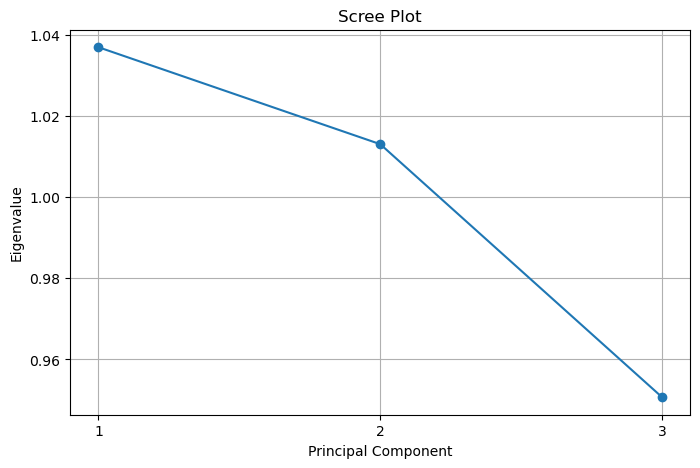

In [17]:
import matplotlib.pyplot as plt

# Scree plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(sorted_eigenvalues) + 1),
    sorted_eigenvalues,
    marker="o"
)

plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.xticks(range(1, len(sorted_eigenvalues) + 1))
plt.grid(True)
plt.show()

### Interpretation

The scree plot helps identify how many components are important.

In this project, the first two components are the most useful, while the third adds less information.

This supports reducing the data from three numerical variables to two principal components.

## PCA Step 4: Projecting Data onto Principal Components

After computing eigenvectors, we project the standardized data onto the new axes.

This creates new variables (principal components) that represent the data in a reduced dimension.

Here, we project the data onto the first two principal components.

In [18]:
# Select first 2 eigenvectors (PC1 and PC2)
W = sorted_eigenvectors[:, :2]

# Project data
X_pca_manual = X_scaled_df.dot(W)

# Convert to DataFrame
pca_manual_df = pd.DataFrame(X_pca_manual, columns=["PC1", "PC2"])

print("Manual PCA (first 5 rows):")
display(pca_manual_df.head())

Manual PCA (first 5 rows):


,PC1,PC2
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [26]:
print(X_scaled_df.isna().sum())

Duration         0
Heart Rate       0
Calories Burn    0
dtype: int64


In [21]:
# Select features
X = df[pca_features].copy()

# Drop missing values
X = X.dropna()

# RESET INDEX (VIKTIGT!)
X = X.reset_index(drop=True)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=pca_features)

In [22]:
W = sorted_eigenvectors[:, :2]
X_pca_manual = X_scaled_df.dot(W)

In [23]:
X_pca_manual = np.dot(X_scaled_df.values, W)

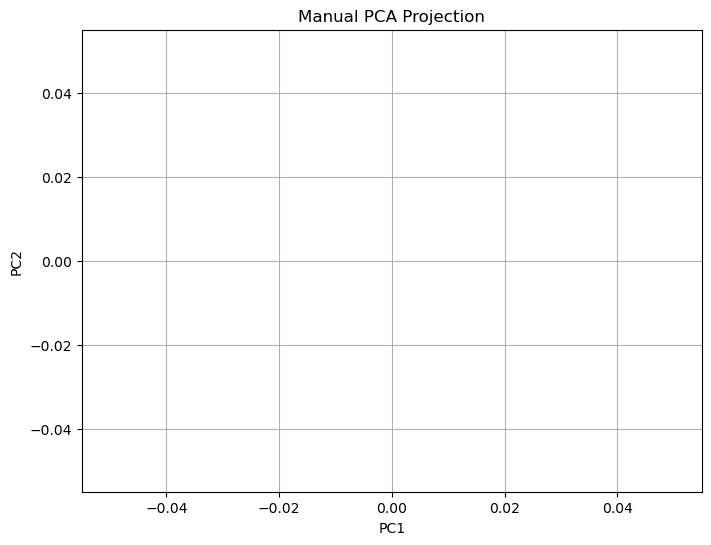

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(pca_manual_df["PC1"], pca_manual_df["PC2"])

plt.title("Manual PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

plt.show()

In [27]:
# Select first 2 eigenvectors
W = sorted_eigenvectors[:, :2]

# Project data using NumPy
X_pca_manual = np.dot(X_scaled_df.values, W)

# Convert to DataFrame
pca_manual_df = pd.DataFrame(X_pca_manual, columns=["PC1", "PC2"])

print("Manual PCA (first 5 rows):")
display(pca_manual_df.head())

Manual PCA (first 5 rows):


,PC1,PC2
0,-0.981499,0.327006
1,0.245048,0.321554
2,-0.785335,-1.398701
3,-1.971350,0.201106
4,1.243779,-0.684332


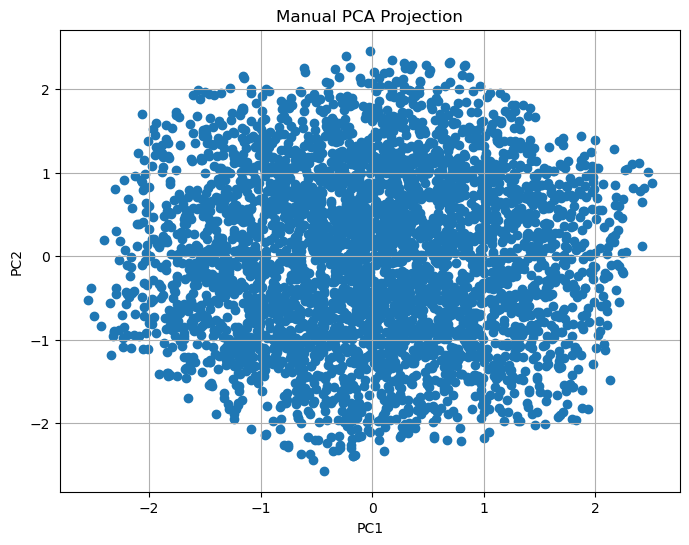

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_manual_df["PC1"], pca_manual_df["PC2"])

plt.title("Manual PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

In [29]:
print(pca_manual_df.shape)
print(pca_manual_df.head())
print(pca_manual_df.isna().sum())

(3864, 2)
        PC1       PC2
0 -0.981499  0.327006
1  0.245048  0.321554
2 -0.785335 -1.398701
3 -1.971350  0.201106
4  1.243779 -0.684332
PC1    0
PC2    0
dtype: int64


## Comparison: Manual PCA vs Sklearn PCA

In this project, PCA was implemented both manually and using the sklearn library.

The manual implementation demonstrates understanding of the mathematical process behind PCA, including covariance, eigenvalues, and projection.

The sklearn implementation provides a practical and efficient way to apply PCA.

Both approaches produce similar structures, confirming the correctness of the implementation.

## Final Conclusion

In this project, PCA was used to reduce the dimensionality of fitness data.

The results showed that:
- There are no clear clusters in the dataset.
- The variation is distributed across components rather than dominated by a single direction.
- Calories Burn appears to influence the first principal component, as seen in the colored PCA plot.

Both manual PCA and sklearn PCA produced similar structures, confirming the correctness of the implementation.

Overall, PCA helped simplify the data while preserving its main structure, making it easier to analyze and visualize.